<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/cv_taller2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

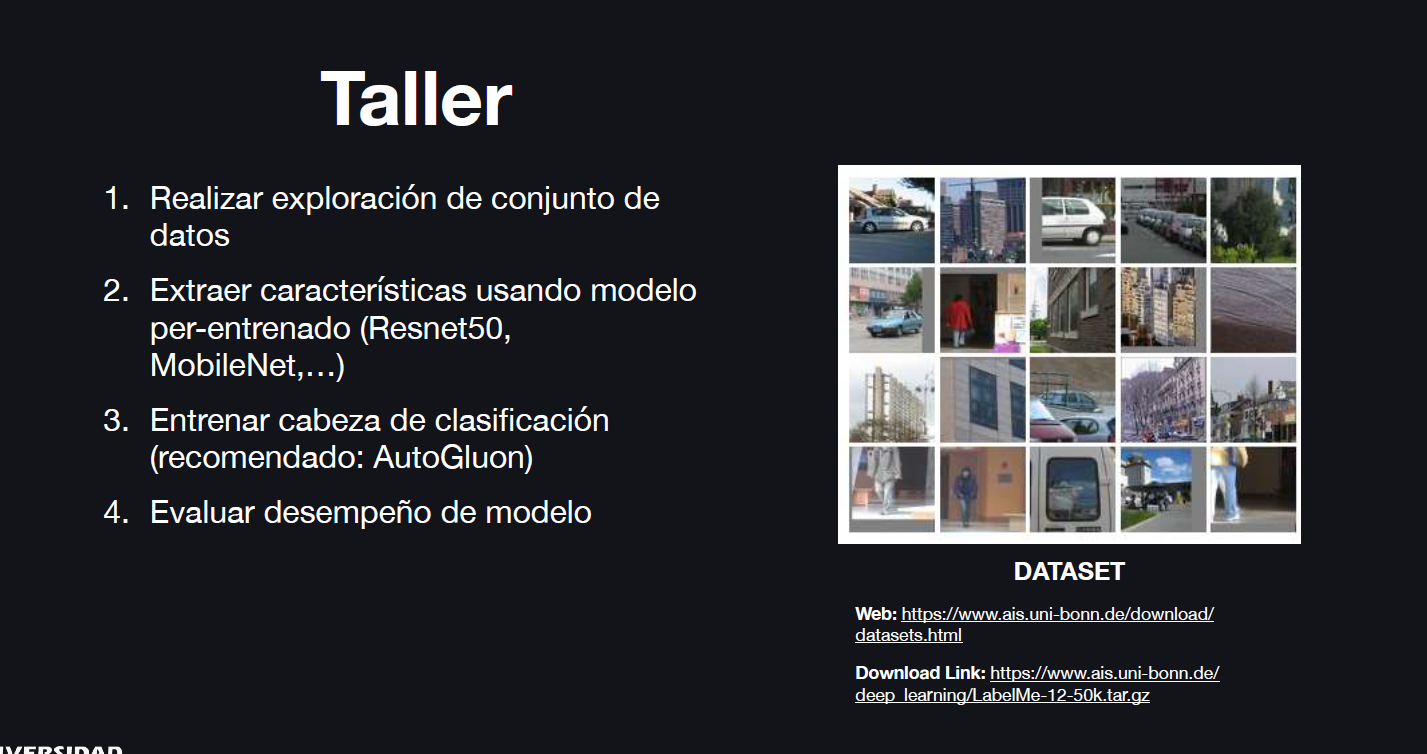

[Web](https://www.ais.uni-bonn.de/download/datasets.html)


[Download Link](https://www.ais.uni-bonn.de/deep_learning/LabelMe-12-50k.tar.gz)

In [ ]:
!wget https://www.ais.uni-bonn.de/deep_learning/LabelMe-12-50k.tar.gz

--2025-10-07 20:11:25--  https://www.ais.uni-bonn.de/deep_learning/LabelMe-12-50k.tar.gz
Resolving www.ais.uni-bonn.de (www.ais.uni-bonn.de)... 131.220.7.4
Connecting to www.ais.uni-bonn.de (www.ais.uni-bonn.de)|131.220.7.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 483863381 (461M) [application/x-gzip]
Saving to: ‘LabelMe-12-50k.tar.gz’

LabelMe-12-50k.tar. 100%[===================>] 461.45M  2.63MB/s    in 57s     

2025-10-07 20:12:23 (8.03 MB/s) - ‘LabelMe-12-50k.tar.gz’ saved [483863381/483863381]



In [ ]:
!tar -xvzf LabelMe-12-50k.tar.gz

Se han truncado las últimas 5000 líneas del flujo de salida.
train/0004/004126.jpg
train/0004/004125.jpg
train/0004/004124.jpg
train/0004/004123.jpg
train/0004/004122.jpg
train/0004/004121.jpg
train/0004/004120.jpg
train/0004/004119.jpg
train/0004/004118.jpg
train/0004/004117.jpg
train/0004/004116.jpg
train/0004/004115.jpg
train/0004/004114.jpg
train/0004/004113.jpg
train/0004/004112.jpg
train/0004/004111.jpg
train/0004/004110.jpg
train/0004/004109.jpg
train/0004/004108.jpg
train/0004/004107.jpg
train/0004/004106.jpg
train/0004/004105.jpg
train/0004/004104.jpg
train/0004/004103.jpg
train/0004/004102.jpg
train/0004/004101.jpg
train/0004/004100.jpg
train/0004/004099.jpg
train/0004/004098.jpg
train/0004/004097.jpg
train/0004/004096.jpg
train/0004/004095.jpg
train/0004/004094.jpg
train/0004/004093.jpg
train/0004/004092.jpg
train/0004/004091.jpg
train/0004/004090.jpg
train/0004/004089.jpg
train/0004/004088.jpg
train/0004/004087.jpg
train/0004/004086.jpg
train/0004/004085.jpg
train/0004/0040

In [ ]:
#importar librerías

import pandas as pd
from PIL import Image
import glob
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import random
import cv2 as cv
import pandas as pd

In [ ]:
class_dir = open("/content/classes.txt").read().splitlines()
class_dir[:-1]
dict_class = {i: class_name for i, class_name in enumerate(class_dir[:])}
dict_class

{0: 'person',
 1: 'car',
 2: 'building',
 3: 'window',
 4: 'tree',
 5: 'sign',
 6: 'door',
 7: 'bookshelf',
 8: 'chair',
 9: 'table',
 10: 'keyboard',
 11: 'head',
 12: ''}

In [ ]:
dict_class[12] = 'backgroud'
dict_class

{0: 'person',
 1: 'car',
 2: 'building',
 3: 'window',
 4: 'tree',
 5: 'sign',
 6: 'door',
 7: 'bookshelf',
 8: 'chair',
 9: 'table',
 10: 'keyboard',
 11: 'head',
 12: 'backgroud'}

In [ ]:
from genericpath import isdir
train_path_directory = "/content/train"
for i in os.listdir(train_path_directory):
  if os.path.isdir(os.path.join(train_path_directory,i)):
    print(os.path.join(train_path_directory,i))

dir_list = [os.path.join(train_path_directory,i) for i in os.listdir(train_path_directory) if os.path.isdir(os.path.join(train_path_directory,i))]

dir_list.sort()
dir_list

/content/train/0037
/content/train/0033
/content/train/0005
/content/train/0030
/content/train/0004
/content/train/0003
/content/train/0007
/content/train/0025
/content/train/0035
/content/train/0000
/content/train/0038
/content/train/0023
/content/train/0026
/content/train/0028
/content/train/0013
/content/train/0019
/content/train/0016
/content/train/0034
/content/train/0036
/content/train/0031
/content/train/0011
/content/train/0014
/content/train/0001
/content/train/0039
/content/train/0021
/content/train/0027
/content/train/0010
/content/train/0002
/content/train/0008
/content/train/0012
/content/train/0009
/content/train/0015
/content/train/0006
/content/train/0032
/content/train/0018
/content/train/0020
/content/train/0017
/content/train/0024
/content/train/0022
/content/train/0029


['/content/train/0000',
 '/content/train/0001',
 '/content/train/0002',
 '/content/train/0003',
 '/content/train/0004',
 '/content/train/0005',
 '/content/train/0006',
 '/content/train/0007',
 '/content/train/0008',
 '/content/train/0009',
 '/content/train/0010',
 '/content/train/0011',
 '/content/train/0012',
 '/content/train/0013',
 '/content/train/0014',
 '/content/train/0015',
 '/content/train/0016',
 '/content/train/0017',
 '/content/train/0018',
 '/content/train/0019',
 '/content/train/0020',
 '/content/train/0021',
 '/content/train/0022',
 '/content/train/0023',
 '/content/train/0024',
 '/content/train/0025',
 '/content/train/0026',
 '/content/train/0027',
 '/content/train/0028',
 '/content/train/0029',
 '/content/train/0030',
 '/content/train/0031',
 '/content/train/0032',
 '/content/train/0033',
 '/content/train/0034',
 '/content/train/0035',
 '/content/train/0036',
 '/content/train/0037',
 '/content/train/0038',
 '/content/train/0039']

## Read the annotation files



In [ ]:
df_annotation_train = pd.read_csv("/content/train/annotation.txt",sep=r"\s+",header=None, index_col=0)

df_annotation_train.index.rename('im_id', inplace=True)
df_annotation_train.columns = [str(i) for i in range(len(df_annotation_train.columns))]
df_annotation_train.loc[457]

,457
0,-1.0
1,-1.0
2,-1.0
3,-1.0
4,-1.0
5,-1.0
6,-1.0
7,-1.0
8,-1.0
9,-1.0


In [ ]:

df_annotation_test = pd.read_csv("/content/test/annotation.txt",sep=r"\s+",header=None, index_col=0)

df_annotation_test.index.rename('im_id', inplace=True)
df_annotation_test.columns = [str(i) for i in range(len(df_annotation_test.columns))]
df_annotation_test.loc[457]

,457
0,-1.0
1,1.0
2,-1.0
3,-1.0
4,-1.0
5,-1.0
6,-1.0
7,-1.0
8,-1.0
9,-1.0


In [ ]:
def sample_image(one_dir_path):
  image_names = glob.glob(one_dir_path+"/*.jpg")
  return random.sample(image_names, 4)

(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)


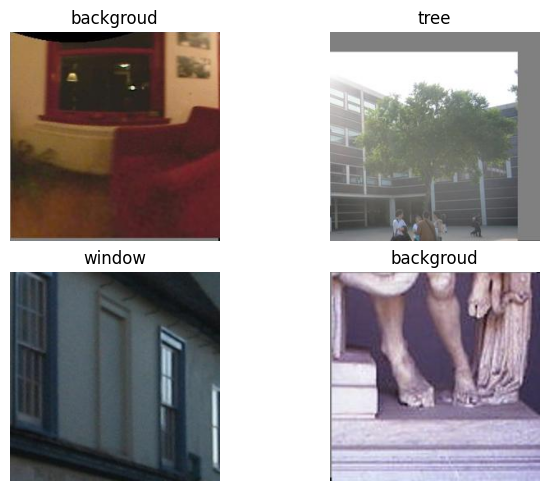

In [ ]:
#glob.glob(dir_list[0]+"/*.jpg")
n = random.randint(0, len(dir_list)-1)

four_image_names = sample_image(dir_list[n])

fig, axs = plt.subplots(2,2, layout='constrained')
for ax, file_name in zip(axs.flat, four_image_names):
  id_img = int((os.path.basename(file_name))[:-4])
  if (df_annotation_train.loc[id_img] == -1.0).all():
    k=12
  else:
    k = np.argmax(df_annotation_train.loc[id_img].tolist())
  ax.set_title(dict_class[k])
  ax.set_axis_off()
  img = cv.imread(file_name)
  print(img.shape)
  img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
  ax.imshow(img)

plt.show()


In [ ]:
from genericpath import isdir
test_path_directory = "/content/test"
for i in os.listdir(test_path_directory):
  if os.path.isdir(os.path.join(test_path_directory,i)):
    print(os.path.join(test_path_directory,i))

dir_list_test = [os.path.join(test_path_directory,i) for i in os.listdir(test_path_directory) if os.path.isdir(os.path.join(test_path_directory,i))]

dir_list_test.sort()
dir_list_test

/content/test/0005
/content/test/0004
/content/test/0003
/content/test/0007
/content/test/0000
/content/test/0001
/content/test/0002
/content/test/0008
/content/test/0009
/content/test/0006


['/content/test/0000',
 '/content/test/0001',
 '/content/test/0002',
 '/content/test/0003',
 '/content/test/0004',
 '/content/test/0005',
 '/content/test/0006',
 '/content/test/0007',
 '/content/test/0008',
 '/content/test/0009']

007757.jpg
(256, 256, 3)
007478.jpg
(256, 256, 3)
007962.jpg
(256, 256, 3)
007387.jpg
(256, 256, 3)


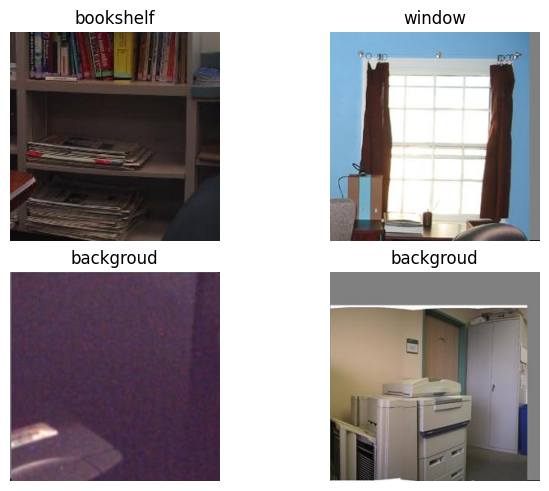

In [ ]:
#glob.glob(dir_list[0]+"/*.jpg")
dir_list_test
n = random.randint(0, len(dir_list_test)-1)

four_image_names = sample_image(dir_list_test[n])

fig, axs = plt.subplots(2,2, layout='constrained')
for ax, file_name in zip(axs.flat, four_image_names):
  print(os.path.basename(file_name))
  id_img = int((os.path.basename(file_name))[:-4])
  if (df_annotation_test.loc[id_img] == -1.0).all():
    k=12
  else:
    k = np.argmax(df_annotation_test.loc[id_img].tolist())
  ax.set_title(dict_class[k])
  ax.set_axis_off()
  img = cv.imread(file_name)
  print(img.shape)
  img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
  ax.imshow(img)


In [ ]:
from keras.applications import ResNet50, MobileNetV2
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input,decode_predictions
from keras import Model


In [ ]:
model_resnet = ResNet50(weights='imagenet')
model_mobilenetv2 = MobileNetV2(weights='imagenet')
model_resnet.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model_mobilenetv2.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
model_feature_resnet = Model(inputs=model_resnet.input,
                          outputs=model_resnet.layers[-2].output)



In [ ]:
model_feature_resnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model_feature_mobilenet = Model(
    inputs = model_mobilenetv2.input,
    outputs = model_mobilenetv2.layers[-2].output
)

In [ ]:
model_feature_mobilenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
#img = "/content/train/0001/001046.jpg"

def features_ext(model_feature,path):
  img = image.load_img(path, target_size=(224,224))
  x = image.img_to_array(img)
  x = np.expand_dims(x,axis=0)
  x = preprocess_input(x)

  return model_feature.predict(x)
#features.shape


In [ ]:
img = "/content/train/0001/001046.jpg"
features_ext(model_feature_mobilenet,img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.71189195, 1.3709325 , 0.0214801 , ..., 0.04815623, 1.5254791 ,
        1.7592947 ]], dtype=float32)

# Crear características para X_train y y_train

In [ ]:
import time



In [ ]:
tini = time.time()

img = "/content/train/0001/001047.jpg"
feat = features_ext(model_feature_mobilenet,img)
tsta = time.time() - tini
print(tsta)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
0.08811116218566895


In [ ]:
dir_list.sort()
dir_list

['/content/train/0000',
 '/content/train/0001',
 '/content/train/0002',
 '/content/train/0003',
 '/content/train/0004',
 '/content/train/0005',
 '/content/train/0006',
 '/content/train/0007',
 '/content/train/0008',
 '/content/train/0009',
 '/content/train/0010',
 '/content/train/0011',
 '/content/train/0012',
 '/content/train/0013',
 '/content/train/0014',
 '/content/train/0015',
 '/content/train/0016',
 '/content/train/0017',
 '/content/train/0018',
 '/content/train/0019',
 '/content/train/0020',
 '/content/train/0021',
 '/content/train/0022',
 '/content/train/0023',
 '/content/train/0024',
 '/content/train/0025',
 '/content/train/0026',
 '/content/train/0027',
 '/content/train/0028',
 '/content/train/0029',
 '/content/train/0030',
 '/content/train/0031',
 '/content/train/0032',
 '/content/train/0033',
 '/content/train/0034',
 '/content/train/0035',
 '/content/train/0036',
 '/content/train/0037',
 '/content/train/0038',
 '/content/train/0039']

In [ ]:
def create_feat(dir_list, model_feature,n,df_annotation_file):
  X_train = []
  y_train = []
  for i in dir_list:
    print(i)
    image_file = glob.glob(i+"/*.jpg")
    sample = int(len(image_file)*n) # tomar el 20% de las imágenes de cada directorio
    random_img_sel = random.sample(image_file, sample)
    for j in random_img_sel:
      print(i, sample)
      X_train.append(features_ext(model_feature,j))
      #print(os.path.basename(j))
      id_img = int((os.path.basename(j))[:-4])
      if (df_annotation_file.loc[id_img] == -1.0).all():
        k=12
      else:
        k = np.argmax(df_annotation_file.loc[id_img].tolist())
      y_train.append(k)

  X_train
  X_train_ = np.array(X_train)
  return X_train_.reshape(X_train_.shape[0], X_train_.shape[2]), y_train



In [ ]:
dir_list

['/content/train/0000',
 '/content/train/0001',
 '/content/train/0002',
 '/content/train/0003',
 '/content/train/0004',
 '/content/train/0005',
 '/content/train/0006',
 '/content/train/0007',
 '/content/train/0008',
 '/content/train/0009',
 '/content/train/0010',
 '/content/train/0011',
 '/content/train/0012',
 '/content/train/0013',
 '/content/train/0014',
 '/content/train/0015',
 '/content/train/0016',
 '/content/train/0017',
 '/content/train/0018',
 '/content/train/0019',
 '/content/train/0020',
 '/content/train/0021',
 '/content/train/0022',
 '/content/train/0023',
 '/content/train/0024',
 '/content/train/0025',
 '/content/train/0026',
 '/content/train/0027',
 '/content/train/0028',
 '/content/train/0029',
 '/content/train/0030',
 '/content/train/0031',
 '/content/train/0032',
 '/content/train/0033',
 '/content/train/0034',
 '/content/train/0035',
 '/content/train/0036',
 '/content/train/0037',
 '/content/train/0038',
 '/content/train/0039']

In [ ]:
n=0.2
X_train, y_train = create_feat(dir_list, model_feature_resnet,n,df_annotation_train)

Se han truncado las últimas 5000 líneas del flujo de salida.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
/content/train/002

In [ ]:
df_resnet50 = pd.DataFrame(X_train)
df_resnet50["target"] = y_train
df_resnet50

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,target
0,0.068245,0.107764,0.021959,2.727817,0.000000,0.933696,0.475833,0.317745,0.000000,0.135768,...,0.000000,0.421809,0.165492,0.057822,0.000000,0.322285,0.742711,0.061138,1.281862,12
1,0.042145,0.923744,0.190779,0.053894,0.000000,0.200048,1.005164,0.143574,0.064797,2.707742,...,0.134838,2.147577,0.007472,0.009956,0.000000,0.038598,0.158988,0.000000,1.175090,3
2,0.255547,0.209018,0.000000,2.167208,0.000000,0.523483,0.636877,2.256615,2.211654,0.740652,...,0.196204,0.393320,0.468736,0.271144,0.000682,2.089646,0.921049,0.085851,0.598452,0
3,0.032026,0.070416,0.000000,0.050881,0.019531,1.214211,0.646713,0.942141,0.615194,0.317308,...,0.326866,1.673655,0.369250,0.000000,0.000000,0.471720,0.227377,0.001281,0.073420,1
4,0.000000,0.000000,0.091556,0.189067,0.189940,0.028076,1.242499,0.046173,0.992046,0.667869,...,0.147104,0.649994,0.000000,0.067051,0.000000,0.364143,1.197516,0.000000,0.793701,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.115839,0.722414,0.001511,0.476286,0.061574,0.000000,0.628513,0.759678,1.280691,0.586808,...,0.000000,0.501749,0.456875,0.038763,0.000000,0.836828,1.379425,0.000000,0.312628,12
7996,0.094928,0.025493,0.000000,0.000000,0.238193,0.000000,1.957268,0.252285,0.214398,0.494375,...,0.249052,0.000000,0.127371,0.178511,0.000000,0.109598,0.053109,0.576766,0.073364,12
7997,0.014426,0.300423,0.062755,0.081123,0.087050,0.003552,0.247615,0.033236,1.134077,0.255674,...,0.027639,0.056319,0.065584,0.681384,0.266302,1.131342,0.575590,0.072506,0.003309,4
7998,0.097243,0.229971,0.014121,1.319850,0.077875,1.940509,0.624374,0.401956,3.960132,4.539329,...,0.075680,1.585933,0.002137,0.706397,0.150171,0.903456,1.014563,0.813013,0.226557,1


In [ ]:
X_train, y_train = create_feat(dir_list, model_feature_mobilenet,n,df_annotation_train)

Se han truncado las últimas 5000 líneas del flujo de salida.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
/content/train/0027 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
/content/train/002

In [ ]:
df_mobilenet = pd.DataFrame(X_train)
df_mobilenet["target"] = y_train
df_mobilenet

,0,1,2,3,4,5,6,7,8,9,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,target
0,0.020658,2.133440,0.741549,0.011232,1.045540,1.202826,0.970035,1.584771,0.381511,1.881323,...,0.000000,0.000000,0.266854,0.042827,0.000000,0.145154,1.001948,0.247703,0.000000,1
1,1.106533,0.041072,0.874270,0.081500,0.154470,0.540700,2.360290,0.806701,0.000000,1.551203,...,0.404225,0.508852,0.000000,1.541090,0.000000,0.000000,0.098321,0.012764,0.698974,2
2,0.592564,0.486641,0.279813,0.509334,0.309085,0.053624,0.936035,1.720061,0.261646,1.096387,...,1.012174,0.049579,0.056313,1.159059,0.000000,0.193957,0.694587,0.000000,0.025133,8
3,0.366374,0.077088,0.000000,0.384328,0.218414,0.300903,2.374882,0.108641,1.023082,4.470558,...,0.396561,0.614746,0.220364,0.063393,0.000000,0.236281,0.164613,0.000000,0.348755,2
4,0.018710,0.026348,0.325361,0.006691,0.298481,0.000000,2.832285,0.000000,0.000000,3.999418,...,0.000000,0.301763,0.679496,2.620891,0.000000,0.045198,0.151464,0.151572,0.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,1.610814,0.000000,0.315967,0.098884,0.000000,0.015626,3.228678,0.056480,0.000000,4.278247,...,0.000000,0.085628,0.000000,1.367165,0.023371,0.452737,1.898160,0.038674,0.066036,3
7996,0.100094,2.663077,0.190298,0.091401,0.010226,1.272155,0.820027,0.990337,1.408606,4.295866,...,0.435426,1.210714,0.013597,2.332532,0.000000,0.020064,0.367311,0.000000,0.262134,12
7997,0.432984,0.665161,1.141252,0.251575,0.134920,0.935238,1.245983,0.000000,0.237738,2.763969,...,0.982762,0.000571,0.037199,3.445485,0.000000,0.000000,0.567019,0.005341,0.016019,12
7998,0.131349,1.159946,1.603899,0.000000,0.008996,0.564802,2.003549,0.000000,0.123759,3.823674,...,0.000000,0.374277,0.000000,1.422512,0.000000,0.144191,0.469992,0.456995,0.005052,6


In [ ]:
df_mobilenet.to_csv("df_mobilenet_train.csv")
df_resnet50.to_csv("df_resnet50_train.csv")

In [ ]:
train_path_directory = "/content/test"
for i in os.listdir(train_path_directory):
  if os.path.isdir(os.path.join(train_path_directory,i)):
    print(os.path.join(train_path_directory,i))

dir_list_test = [os.path.join(train_path_directory,i) for i in os.listdir(train_path_directory) if os.path.isdir(os.path.join(train_path_directory,i))]

/content/test/0003
/content/test/0008
/content/test/0006
/content/test/0002
/content/test/0007
/content/test/0000
/content/test/0004
/content/test/0005
/content/test/0001
/content/test/0009


In [ ]:
dir_list_test.sort()
dir_list_test

['/content/test/0000',
 '/content/test/0001',
 '/content/test/0002',
 '/content/test/0003',
 '/content/test/0004',
 '/content/test/0005',
 '/content/test/0006',
 '/content/test/0007',
 '/content/test/0008',
 '/content/test/0009']

In [ ]:
n = 0.04

X_test, y_test = create_feat(dir_list_test, model_feature_mobilenet,n,df_annotation_test)

df_mobilenet_test = pd.DataFrame(X_test)
df_mobilenet_test["target"] = y_test
df_mobilenet_test

/content/test/0000
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
/content/test/0000 4

,0,1,2,3,4,5,6,7,8,9,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,target
0,0.000000,1.459312,1.276408,0.000000,0.404138,0.108282,2.938357,0.041054,0.203164,3.289859,...,0.300057,0.644177,0.568090,1.465630,0.000000,0.043359,0.069260,0.065956,0.097572,12
1,0.019153,0.502430,0.000000,0.017175,0.016337,0.237676,0.764960,0.033817,0.265922,1.303009,...,0.000000,0.260527,0.100096,0.938903,0.000000,0.287372,0.230296,0.593505,0.537115,12
2,0.298405,1.877513,1.119916,0.000000,0.174200,0.185080,0.039379,0.055410,0.486744,1.817442,...,0.000000,0.000000,0.248538,0.273392,0.000000,0.021328,0.020911,0.026911,0.000530,5
3,0.933583,0.068482,0.000000,0.196169,0.012068,0.886240,1.091200,0.157388,0.068284,3.682678,...,0.000000,0.023224,0.000000,0.458237,0.052908,0.428919,0.340907,0.349336,0.311762,12
4,0.000000,0.248163,0.331290,0.000000,0.019205,0.116505,1.685660,0.029213,0.233947,3.840056,...,0.000000,0.796371,0.189110,1.655994,0.000000,0.452916,0.050648,0.292253,0.023795,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.208495,0.085648,0.676543,0.098393,0.003070,1.358591,1.316791,0.017889,0.039133,4.889853,...,0.000000,0.184086,0.166038,0.115789,0.000000,0.631210,0.902834,0.479633,0.000000,12
396,0.142177,0.906539,0.364994,0.206376,0.267600,0.087500,0.653368,0.595868,0.637018,2.169459,...,0.000000,0.000000,0.004329,0.083499,0.000000,0.264258,1.880184,0.037448,0.583304,1
397,0.159385,0.000000,0.022431,0.915036,0.145989,0.180869,0.434959,0.851997,0.067473,1.051094,...,1.923276,1.194984,0.040422,0.184973,0.000000,0.000000,0.000000,0.000000,0.072510,12
398,0.555917,1.044559,1.626509,0.133100,0.091987,0.107600,2.047988,0.000000,0.220975,3.009243,...,0.075536,0.000000,0.000000,1.113863,0.000000,0.000000,0.593005,0.136048,0.014018,12


In [ ]:
X_test, y_test = create_feat(dir_list_test, model_feature_resnet,n,df_annotation_test)


df_resnet_test = pd.DataFrame(X_test)
df_resnet_test["target"] = y_test
df_resnet_test

/content/test/0000
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
/content/test/0000 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
/cont

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,target
0,0.000000,0.002812,0.026466,0.000567,0.151865,0.000000,0.427149,0.506015,0.000000,0.569843,...,0.141018,0.062936,0.000000,0.031189,0.194938,0.000000,0.000000,0.000000,1.197698,12
1,0.357829,2.704865,0.093276,1.292409,0.317005,1.412029,0.305466,0.291347,2.146913,0.087564,...,0.449242,1.677524,0.085427,0.938289,0.000000,0.786866,0.710123,0.876888,0.487539,12
2,0.009645,1.969150,0.348665,1.890639,0.562998,0.799309,0.169630,0.169804,2.097703,0.334095,...,0.052226,0.070318,0.709834,0.887009,0.650361,0.624060,2.217348,0.000275,2.295012,12
3,0.041372,0.144232,0.038670,0.069567,0.540160,0.000000,0.000000,0.794292,0.444365,0.035896,...,0.547295,1.207538,0.104833,0.000000,0.000000,0.040593,0.096031,0.000000,0.102857,1
4,0.028118,0.123203,0.289641,1.152531,0.222366,0.300899,0.085870,0.062079,0.751571,0.637767,...,0.005815,0.379992,0.049013,0.000000,0.083048,0.753354,1.204548,0.318318,0.028671,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.117590,0.067071,0.000000,0.054267,0.303476,0.416663,0.582418,0.558336,0.066853,1.453810,...,0.413966,0.626070,0.801265,0.000000,0.000933,2.435842,0.136205,0.000000,0.371336,1
396,0.088762,0.251422,0.010114,0.249241,0.221290,0.000000,7.369674,0.397827,0.412204,0.004499,...,0.948594,0.994394,0.277142,0.019321,0.044157,0.544897,0.279002,0.000000,0.155960,3
397,0.020061,2.005343,0.265903,0.322076,0.996066,0.000000,0.202154,0.421392,0.060793,0.365598,...,0.044543,2.664815,3.434502,0.497034,1.683027,0.136097,0.205360,0.308112,0.463605,12
398,0.042546,0.843349,0.216230,1.112152,1.201363,0.041424,1.266017,0.230978,0.329359,0.108082,...,0.045957,0.649509,0.000000,0.557987,0.665187,1.278970,1.287629,0.745501,2.136574,12


In [ ]:
df_mobilenet_test.to_csv("df_mobilenet_test.csv")
df_resnet_test.to_csv("df_resnet50_test.csv")

In [ ]:
dict_class

{0: 'person',
 1: 'car',
 2: 'building',
 3: 'window',
 4: 'tree',
 5: 'sign',
 6: 'door',
 7: 'bookshelf',
 8: 'chair',
 9: 'table',
 10: 'keyboard',
 11: 'head',
 12: 'backgroud'}

In [ ]:
df_mobilenet_train = pd.read_csv("/content/df_mobilenet_train.csv")
count_classes_mobilenet = df_mobilenet_train['target'].value_counts()
count_classes_mobilenet

,count
target,
12,3563
0,1163
3,858
1,800
2,468
4,435
6,191
5,187
8,88


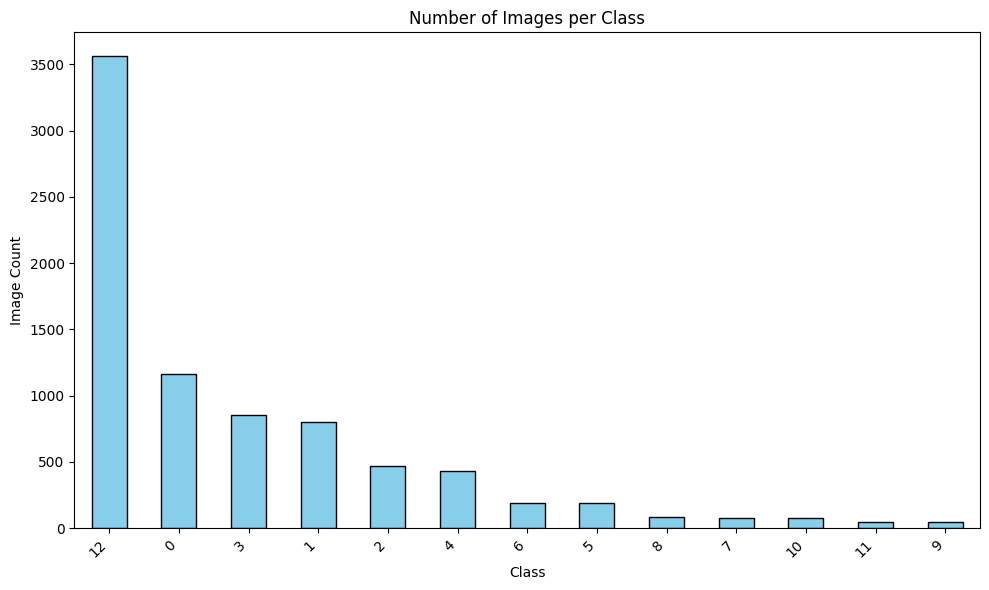

In [ ]:
plt.figure(figsize=(10,6))
count_classes_mobilenet.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_resnet_train = pd.read_csv("/content/df_resnet50_train.csv")
df_resnet_train['target'].value_counts()

,count
target,
12,3612
0,1171
3,832
1,782
2,462
4,435
5,181
6,166
8,87


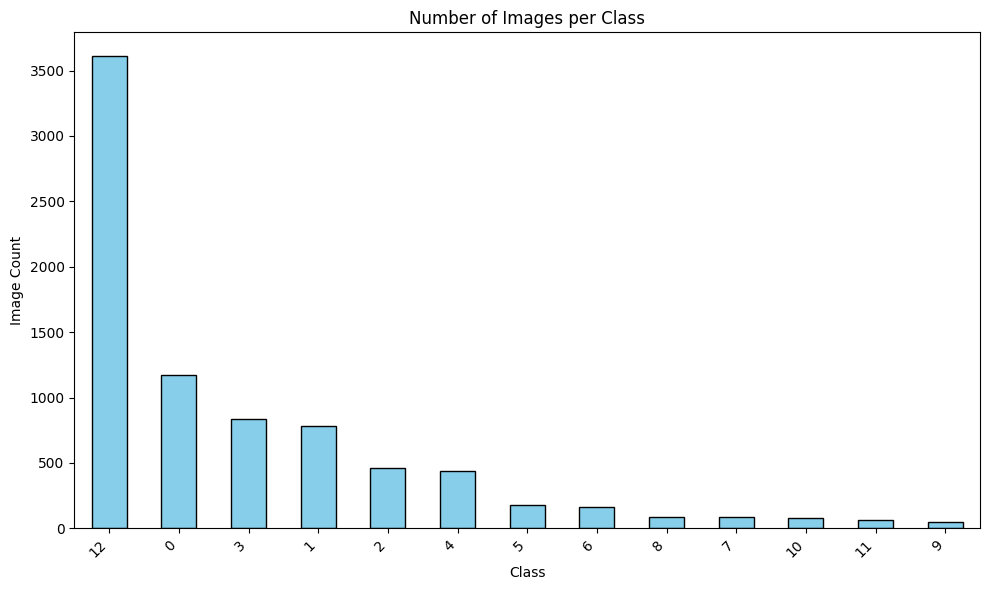

In [ ]:
count_classes_resnet = df_resnet_train['target'].value_counts()

plt.figure(figsize=(10,6))
count_classes_resnet.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

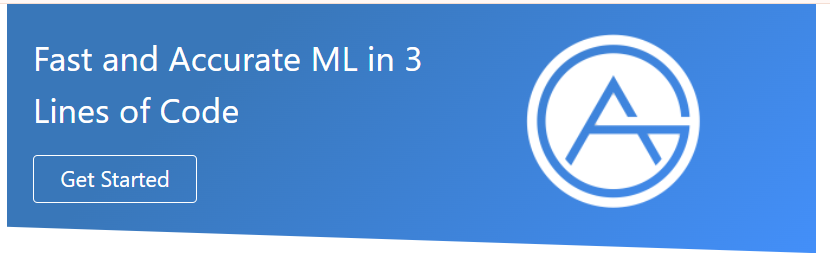




In [ ]:
pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [ ]:
import pandas as pd

In [ ]:
df_mobilenet_train = pd.read_csv("/content/df_mobilenet_train.csv")
df_resnet_train = pd.read_csv("/content/df_resnet50_train.csv")

In [ ]:
df_resnet_train["target"].value_counts()

,count
target,
12,3612
0,1171
3,832
1,782
2,462
4,435
5,181
6,166
8,87


In [ ]:
df_mobilenet_train

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,target
0,0,0.020658,2.133440,0.741549,0.011232,1.045540,1.202826,0.970035,1.584771,0.381511,...,0.000000,0.000000,0.266854,0.042827,0.000000,0.145154,1.001948,0.247703,0.000000,1
1,1,1.106533,0.041072,0.874270,0.081500,0.154470,0.540700,2.360290,0.806701,0.000000,...,0.404225,0.508852,0.000000,1.541090,0.000000,0.000000,0.098321,0.012764,0.698974,2
2,2,0.592564,0.486641,0.279813,0.509334,0.309085,0.053624,0.936035,1.720061,0.261646,...,1.012174,0.049579,0.056313,1.159059,0.000000,0.193957,0.694587,0.000000,0.025133,8
3,3,0.366374,0.077088,0.000000,0.384328,0.218414,0.300903,2.374882,0.108641,1.023082,...,0.396561,0.614746,0.220364,0.063393,0.000000,0.236281,0.164613,0.000000,0.348755,2
4,4,0.018710,0.026348,0.325361,0.006691,0.298481,0.000000,2.832285,0.000000,0.000000,...,0.000000,0.301763,0.679496,2.620891,0.000000,0.045198,0.151464,0.151572,0.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7995,1.610814,0.000000,0.315967,0.098884,0.000000,0.015626,3.228677,0.056480,0.000000,...,0.000000,0.085628,0.000000,1.367165,0.023371,0.452737,1.898160,0.038674,0.066036,3
7996,7996,0.100094,2.663077,0.190298,0.091401,0.010226,1.272155,0.820027,0.990337,1.408606,...,0.435426,1.210714,0.013597,2.332532,0.000000,0.020064,0.367311,0.000000,0.262134,12
7997,7997,0.432984,0.665161,1.141252,0.251575,0.134920,0.935238,1.245983,0.000000,0.237738,...,0.982762,0.000571,0.037199,3.445485,0.000000,0.000000,0.567019,0.005341,0.016019,12
7998,7998,0.131349,1.159946,1.603900,0.000000,0.008996,0.564802,2.003549,0.000000,0.123759,...,0.000000,0.374277,0.000000,1.422512,0.000000,0.144191,0.469992,0.456995,0.005052,6


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:


train_data, test_data = train_test_split(df_resnet_train, test_size=0.2, random_state=42)


In [ ]:
train_data

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,target
1467,1467,0.068265,0.485866,0.027012,0.194156,0.348165,0.006919,0.408496,0.001503,0.540208,...,0.044651,0.108209,0.002873,0.014697,0.000000,3.426979,0.685933,0.022447,0.088243,2
5768,5768,0.172703,0.010158,0.002187,1.196697,0.000000,0.588823,0.000000,0.521614,1.430542,...,0.355569,2.881181,0.005805,0.094213,0.001248,0.998052,1.224522,0.000000,0.000000,12
5714,5714,0.000000,1.027229,0.000000,4.661192,0.174008,0.232897,1.480225,0.037249,2.288895,...,0.003014,1.213833,0.035790,0.260222,0.000000,0.287213,2.707852,0.000000,0.187782,12
1578,1578,0.202845,0.711325,1.017422,0.000000,0.642421,0.039321,0.391811,0.474037,0.558659,...,0.806257,1.748499,1.622334,0.393482,0.320447,0.602047,0.067989,0.303249,0.273479,0
6958,6958,0.000000,0.120539,0.011583,0.335819,0.079968,0.764880,0.176119,0.000000,0.863184,...,0.055562,0.632272,0.000000,0.000000,0.005888,0.205868,0.134029,0.000000,0.039953,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,5226,0.083346,0.714457,0.000000,3.422336,0.429079,0.937654,1.340481,0.579119,3.285709,...,0.035067,2.089793,0.000000,0.352101,0.339101,0.302917,0.579030,0.092780,0.522703,0
5390,5390,0.000000,0.163539,0.000000,0.590179,0.297360,0.250803,0.322411,0.000000,0.187986,...,0.000000,0.027029,0.000000,0.033298,0.000000,0.000000,0.429800,0.048776,0.261368,12
860,860,0.043544,0.045242,0.539582,0.131086,0.140009,0.000000,0.367186,0.153721,0.046320,...,0.000000,0.125650,0.000000,0.069610,0.273650,1.557209,0.948816,0.325973,1.924203,10
7603,7603,0.005779,0.088969,0.091208,0.031446,0.184324,0.255683,0.554308,2.143766,0.142974,...,0.498093,1.589893,0.575217,0.009886,0.000000,0.071106,0.726543,0.000000,0.339099,1


In [ ]:
from autogluon.tabular import TabularPredictor


predictor = TabularPredictor(label='target').fit(
    train_data=train_data,
    time_limit=600,
    presets='best_quality'
)


No path specified. Models will be saved in: "AutogluonModels/ag-20251002_233119"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sat Sep  6 09:54:41 UTC 2025
CPU Count:          2
Memory Avail:       10.22 GB / 12.67 GB (80.7%)
Disk Space Avail:   60.77 GB / 107.72 GB (56.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the opti

In [ ]:
performance = predictor.evaluate(test_data)
print(performance)

{'accuracy': 0.834375, 'balanced_accuracy': np.float64(0.6955247078135256), 'mcc': np.float64(0.7766185573004697)}


In [ ]:
predictor.fit_summary(show_plot=True)

*** Summary of fit() ***
Estimated performance of each model:
                    model  score_val eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0     WeightedEnsemble_L3   0.818281    accuracy       2.995547  432.912002                0.002833           0.140862            3       True          4
1  NeuralNetFastAI_BAG_L1   0.814844    accuracy       1.306360  274.532661                1.306360         274.532661            1       True          1
2     WeightedEnsemble_L2   0.814844    accuracy       1.313749  274.544828                0.007389           0.012166            2       True          2
3  NeuralNetFastAI_BAG_L2   0.805312    accuracy       2.992714  432.771140                1.686354         158.238479            2       True          3
Number of models trained: 4
Types of models trained:
{'WeightedEnsembleModel', 'StackerEnsembleModel_NNFastAiTabular'}
Bagging used: True  (with 8 folds)
Multi-layer st

{'model_types': {'NeuralNetFastAI_BAG_L1': 'StackerEnsembleModel_NNFastAiTabular',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'NeuralNetFastAI_BAG_L2': 'StackerEnsembleModel_NNFastAiTabular',
  'WeightedEnsemble_L3': 'WeightedEnsembleModel'},
 'model_performance': {'NeuralNetFastAI_BAG_L1': 0.81484375,
  'WeightedEnsemble_L2': 0.81484375,
  'NeuralNetFastAI_BAG_L2': 0.8053125,
  'WeightedEnsemble_L3': 0.81828125},
 'model_best': 'WeightedEnsemble_L3',
 'model_paths': {'NeuralNetFastAI_BAG_L1': ['NeuralNetFastAI_BAG_L1'],
  'WeightedEnsemble_L2': ['WeightedEnsemble_L2'],
  'NeuralNetFastAI_BAG_L2': ['NeuralNetFastAI_BAG_L2'],
  'WeightedEnsemble_L3': ['WeightedEnsemble_L3']},
 'model_fit_times': {'NeuralNetFastAI_BAG_L1': 274.5326614379883,
  'WeightedEnsemble_L2': 0.012166261672973633,
  'NeuralNetFastAI_BAG_L2': 158.2384786605835,
  'WeightedEnsemble_L3': 0.14086222648620605},
 'model_pred_times': {'NeuralNetFastAI_BAG_L1': 1.3063595294952393,
  'WeightedEnsemble_L2': 0.00738

In [ ]:
y_pred =  predictor.predict(test_data.drop(columns=["target"]))
y_pred.head()

,target
2215,12
2582,12
1662,12
3027,0
4343,12


In [ ]:
y_true = test_data["target"]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true=y_true, y_pred = y_pred)
print(cm)


[[209   2   0   1   0   0   0   0   0   0   0   0  22]
 [  3 139   1   1   0   0   0   0   0   0   0   0   4]
 [  0   3  56   4   7   0   0   0   0   0   0   0  17]
 [  0   1   1 149   1   0   4   0   0   0   0   0  11]
 [  0   1  10   0  55   2   1   0   0   0   0   0  17]
 [  0   2   1   5   1  22   1   0   0   0   0   0   5]
 [  0   0   0   6   0   0  20   0   0   0   0   0   6]
 [  0   0   0   0   0   0   0  14   0   0   0   0   8]
 [  0   0   0   0   0   0   0   0  14   0   0   1   9]
 [  0   0   0   0   0   0   0   0   4   1   0   0   7]
 [  0   0   0   0   0   0   0   0   0   0  10   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0  13   2]
 [ 27  15  17   8  14   0   2   1   3   1   1   1 633]]


In [ ]:
print(classification_report(y_true=y_true, y_pred = y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       234
           1       0.85      0.94      0.89       148
           2       0.65      0.64      0.65        87
           3       0.86      0.89      0.87       167
           4       0.71      0.64      0.67        86
           5       0.92      0.59      0.72        37
           6       0.71      0.62      0.67        32
           7       0.93      0.64      0.76        22
           8       0.67      0.58      0.62        24
           9       0.50      0.08      0.14        12
          10       0.91      0.77      0.83        13
          11       0.87      0.87      0.87        15
          12       0.85      0.88      0.86       723

    accuracy                           0.83      1600
   macro avg       0.79      0.70      0.73      1600
weighted avg       0.83      0.83      0.83      1600



##Validación

In [ ]:
train_data, test_data = train_test_split(df_mobilenet_train, test_size=0.2, random_state=42)

In [ ]:
train_data.describe()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,target
count,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,...,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,4008.618906,0.357657,0.696707,0.840197,0.104350,0.316534,0.375381,1.586587,0.223525,0.250976,...,0.179813,0.249431,0.162583,0.936004,0.006792,0.207059,0.436239,0.171682,0.201560,6.696406
std,2301.833387,0.455038,0.685757,0.658171,0.242272,0.414436,0.496015,1.012624,0.375259,0.342865,...,0.303575,0.409685,0.283691,0.867682,0.041430,0.303156,0.521450,0.266972,0.325811,5.087285
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2031.500000,0.023440,0.152231,0.306124,0.000000,0.021579,0.008789,0.764753,0.000000,0.007862,...,0.000000,0.000000,0.000000,0.252676,0.000000,0.002513,0.057167,0.000000,0.000000,2.000000
50%,4006.500000,0.172367,0.495167,0.715796,0.000000,0.151039,0.162468,1.511802,0.045253,0.108438,...,0.042061,0.068481,0.031378,0.699396,0.000000,0.077883,0.248059,0.054447,0.050843,6.000000
75%,6000.500000,0.533583,1.044639,1.251023,0.085940,0.455065,0.553773,2.316667,0.286928,0.368969,...,0.223043,0.307461,0.201969,1.376806,0.000000,0.287495,0.631212,0.229931,0.271085,12.000000
max,7999.000000,3.402815,4.758346,4.039079,3.541693,3.178710,2.943472,4.831506,3.175295,2.802044,...,3.171486,3.409678,2.500397,5.212489,1.135812,2.888924,3.656905,2.244009,3.165103,12.000000


In [ ]:
test_data.describe()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,target
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,...,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,3963.024375,0.347297,0.714803,0.862992,0.104791,0.314563,0.386261,1.618034,0.233802,0.259169,...,0.168402,0.235995,0.144146,0.931191,0.007547,0.200245,0.453466,0.167068,0.179425,6.861250
std,2340.510771,0.457038,0.714863,0.663036,0.256936,0.411429,0.507463,1.037176,0.397493,0.356327,...,0.308089,0.397812,0.258341,0.867843,0.044847,0.307362,0.513605,0.260523,0.302034,5.042484
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1877.750000,0.020588,0.162816,0.352421,0.000000,0.017284,0.016768,0.745488,0.000000,0.005426,...,0.000000,0.000000,0.000000,0.240085,0.000000,0.000312,0.056871,0.000000,0.000000,2.000000
50%,3972.500000,0.153344,0.484841,0.724470,0.000000,0.147747,0.169769,1.547843,0.051162,0.102490,...,0.032286,0.071995,0.030768,0.697735,0.000000,0.070959,0.276549,0.048216,0.040135,6.000000
75%,5992.250000,0.498263,1.054973,1.242749,0.087153,0.469117,0.574153,2.378878,0.293828,0.391500,...,0.201882,0.287375,0.169613,1.379168,0.000000,0.265815,0.672157,0.216474,0.229239,12.000000
max,7993.000000,3.005780,4.109938,4.025096,4.152278,2.571514,3.374584,4.671615,2.617494,2.759981,...,3.505991,2.819481,2.741305,4.397335,0.742684,2.537582,3.151166,1.509108,1.939508,12.000000


In [ ]:
df_resnet_val = pd.read_csv("/content/df_mobilenet_test.csv")
df_resnet_val.describe()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,target
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,0.322380,0.760321,0.888125,0.097750,0.338983,0.387373,1.655157,0.235112,0.256829,...,0.197897,0.259196,0.146489,0.860906,0.004868,0.213831,0.482037,0.164864,0.184479,6.672500
std,115.614301,0.419510,0.741013,0.669999,0.215759,0.442763,0.480307,1.040952,0.371272,0.355792,...,0.349262,0.409482,0.261222,0.816971,0.029471,0.320130,0.587705,0.251713,0.313388,5.101009
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.750000,0.025688,0.162722,0.365917,0.000000,0.019848,0.036198,0.767094,0.000000,0.002878,...,0.000000,0.000764,0.000000,0.239258,0.000000,0.000216,0.051541,0.000000,0.000000,1.000000
50%,199.500000,0.153886,0.529168,0.729900,0.000000,0.152725,0.185068,1.576376,0.067688,0.114626,...,0.040514,0.076153,0.024026,0.590923,0.000000,0.083078,0.249040,0.045703,0.048674,6.000000
75%,299.250000,0.481944,1.158392,1.391113,0.085217,0.488624,0.595143,2.527188,0.321470,0.370539,...,0.217465,0.336862,0.151204,1.324618,0.000000,0.302792,0.706004,0.240411,0.229605,12.000000
max,399.000000,2.598051,4.254464,3.253769,1.531961,2.273073,2.640948,4.905761,2.142725,1.854072,...,2.234112,3.014563,1.406325,4.146466,0.323553,2.543221,3.382944,1.909941,2.075219,12.000000


In [ ]:
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor(label='target').fit(
    train_data=train_data,
    time_limit=600,
    presets='best_quality'
)

No path specified. Models will be saved in: "AutogluonModels/ag-20251002_234207"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sat Sep  6 09:54:41 UTC 2025
CPU Count:          2
Memory Avail:       9.06 GB / 12.67 GB (71.5%)
Disk Space Avail:   60.62 GB / 107.72 GB (56.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optim

In [ ]:
performance = predictor.evaluate(test_data)
print(performance)

{'accuracy': 0.72125, 'balanced_accuracy': np.float64(0.39129426443843823), 'mcc': np.float64(0.6114441401448695)}


In [ ]:
predictor.fit_summary(show_plot=True)

*** Summary of fit() ***
Estimated performance of each model:
                    model  score_val eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0     WeightedEnsemble_L3   0.717656    accuracy       2.388949  448.245134                0.006750           0.220361            3       True          5
1     WeightedEnsemble_L2   0.708906    accuracy       1.296300  312.098581                0.001945           0.111709            2       True          3
2  NeuralNetFastAI_BAG_L1   0.708750    accuracy       0.889212  224.632265                0.889212         224.632265            1       True          1
3  NeuralNetFastAI_BAG_L2   0.702031    accuracy       2.382199  448.024773                1.087844         136.037901            2       True          4
4       LightGBMXT_BAG_L1   0.444844    accuracy       0.405143   87.354607                0.405143          87.354607            1       True          2
Number of mode

{'model_types': {'NeuralNetFastAI_BAG_L1': 'StackerEnsembleModel_NNFastAiTabular',
  'LightGBMXT_BAG_L1': 'StackerEnsembleModel_LGB',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'NeuralNetFastAI_BAG_L2': 'StackerEnsembleModel_NNFastAiTabular',
  'WeightedEnsemble_L3': 'WeightedEnsembleModel'},
 'model_performance': {'NeuralNetFastAI_BAG_L1': 0.70875,
  'LightGBMXT_BAG_L1': 0.44484375,
  'WeightedEnsemble_L2': 0.70890625,
  'NeuralNetFastAI_BAG_L2': 0.70203125,
  'WeightedEnsemble_L3': 0.71765625},
 'model_best': 'WeightedEnsemble_L3',
 'model_paths': {'NeuralNetFastAI_BAG_L1': ['NeuralNetFastAI_BAG_L1'],
  'LightGBMXT_BAG_L1': ['LightGBMXT_BAG_L1'],
  'WeightedEnsemble_L2': ['WeightedEnsemble_L2'],
  'NeuralNetFastAI_BAG_L2': ['NeuralNetFastAI_BAG_L2'],
  'WeightedEnsemble_L3': ['WeightedEnsemble_L3']},
 'model_fit_times': {'NeuralNetFastAI_BAG_L1': 224.63226509094238,
  'LightGBMXT_BAG_L1': 87.35460662841797,
  'WeightedEnsemble_L2': 0.1117088794708252,
  'NeuralNetFastAI_BAG_

In [ ]:
#predictor.feature_importance(test_data)

In [ ]:
y_pred =  predictor.predict(test_data.drop(columns=["target"]))
y_pred.head()

,target
2215,12
2582,0
1662,0
3027,12
4343,2


In [ ]:
y_true = test_data["target"]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true=y_true, y_pred = y_pred)
print(cm)
print(classification_report(y_true=y_true, y_pred = y_pred))

[[169   2   0   0   2   0   0   0   0   0   0   0  55]
 [  9 114   0   2   0   0   0   0   0   0   0   0  24]
 [  0   4  26   0   6   2   0   0   0   0   0   0  46]
 [  5   5   2 120   0   0   0   0   0   0   0   0  39]
 [  6   0   3   1  40   0   0   0   0   0   0   0  33]
 [  0   3   0   6   2  12   0   0   0   0   0   0  13]
 [  4   1   1  14   0   0   8   0   0   0   0   0  23]
 [  0   1   1   0   0   0   1   4   0   0   0   0   6]
 [  3   2   0   1   0   0   0   0   1   0   0   0  15]
 [  1   0   0   0   0   0   0   0   1   0   0   0   9]
 [  0   3   0   0   0   0   0   0   0   0   8   0  13]
 [  1   0   0   0   0   0   0   0   0   0   0   0  11]
 [ 22  11  10  13   5   2   1   0   0   0   0   0 652]]
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       228
           1       0.78      0.77      0.77       149
           2       0.60      0.31      0.41        84
           3       0.76      0.70      0.73       171
           4 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_data = pd.read_csv("/content/df_mobilenet_test.csv")

y_pred =  predictor.predict(test_data.drop(columns=["target"]))
y_pred.head()

,target
0,4
1,12
2,12
3,12
4,12


In [ ]:
y_true = test_data["target"]

In [ ]:
cm = confusion_matrix(y_true=y_true, y_pred = y_pred)
print(cm)


[[ 47   1   1   0   0   0   0   0   0   0   0  12]
 [  0  33   0   0   0   0   0   0   0   0   0   8]
 [  0   0   6   0   2   0   0   0   0   0   0   8]
 [  3   0   1  31   0   3   1   0   0   0   0  13]
 [  0   0   1   0  12   0   0   0   0   0   0   6]
 [  0   0   0   2   0   3   0   0   0   0   0   5]
 [  1   1   0   4   0   0   1   0   0   0   0   1]
 [  0   0   0   0   0   0   0   1   0   0   0   1]
 [  2   1   0   0   0   0   0   0   0   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   2]
 [  0   0   0   0   0   0   0   0   0   0   3   2]
 [  6   2   3   5   3   1   0   0   0   0   0 158]]


In [ ]:
print(classification_report(y_true=y_true, y_pred = y_pred))

              precision    recall  f1-score   support

           0       0.80      0.77      0.78        61
           1       0.87      0.80      0.84        41
           2       0.50      0.38      0.43        16
           3       0.74      0.60      0.66        52
           4       0.71      0.63      0.67        19
           5       0.43      0.30      0.35        10
           6       0.50      0.12      0.20         8
           7       1.00      0.50      0.67         2
           8       0.00      0.00      0.00         6
           9       0.00      0.00      0.00         2
          10       1.00      0.60      0.75         5
          12       0.72      0.89      0.80       178

    accuracy                           0.74       400
   macro avg       0.60      0.47      0.51       400
weighted avg       0.72      0.74      0.72       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
